In [154]:


import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

In [155]:
housing = pd.DataFrame(pd.read_csv("/content/heart_statlog_cleveland_hungary_final.csv"))

In [156]:

housing.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


## Data Inspection

In [157]:
housing.shape

(1190, 12)

In [158]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [159]:
housing.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


## Data Cleaning

In [160]:

housing.isnull().sum()*100/housing.shape[0]


,0
age,0.0
sex,0.0
chest pain type,0.0
resting bp s,0.0
cholesterol,0.0
fasting blood sugar,0.0
resting ecg,0.0
max heart rate,0.0
exercise angina,0.0
oldpeak,0.0


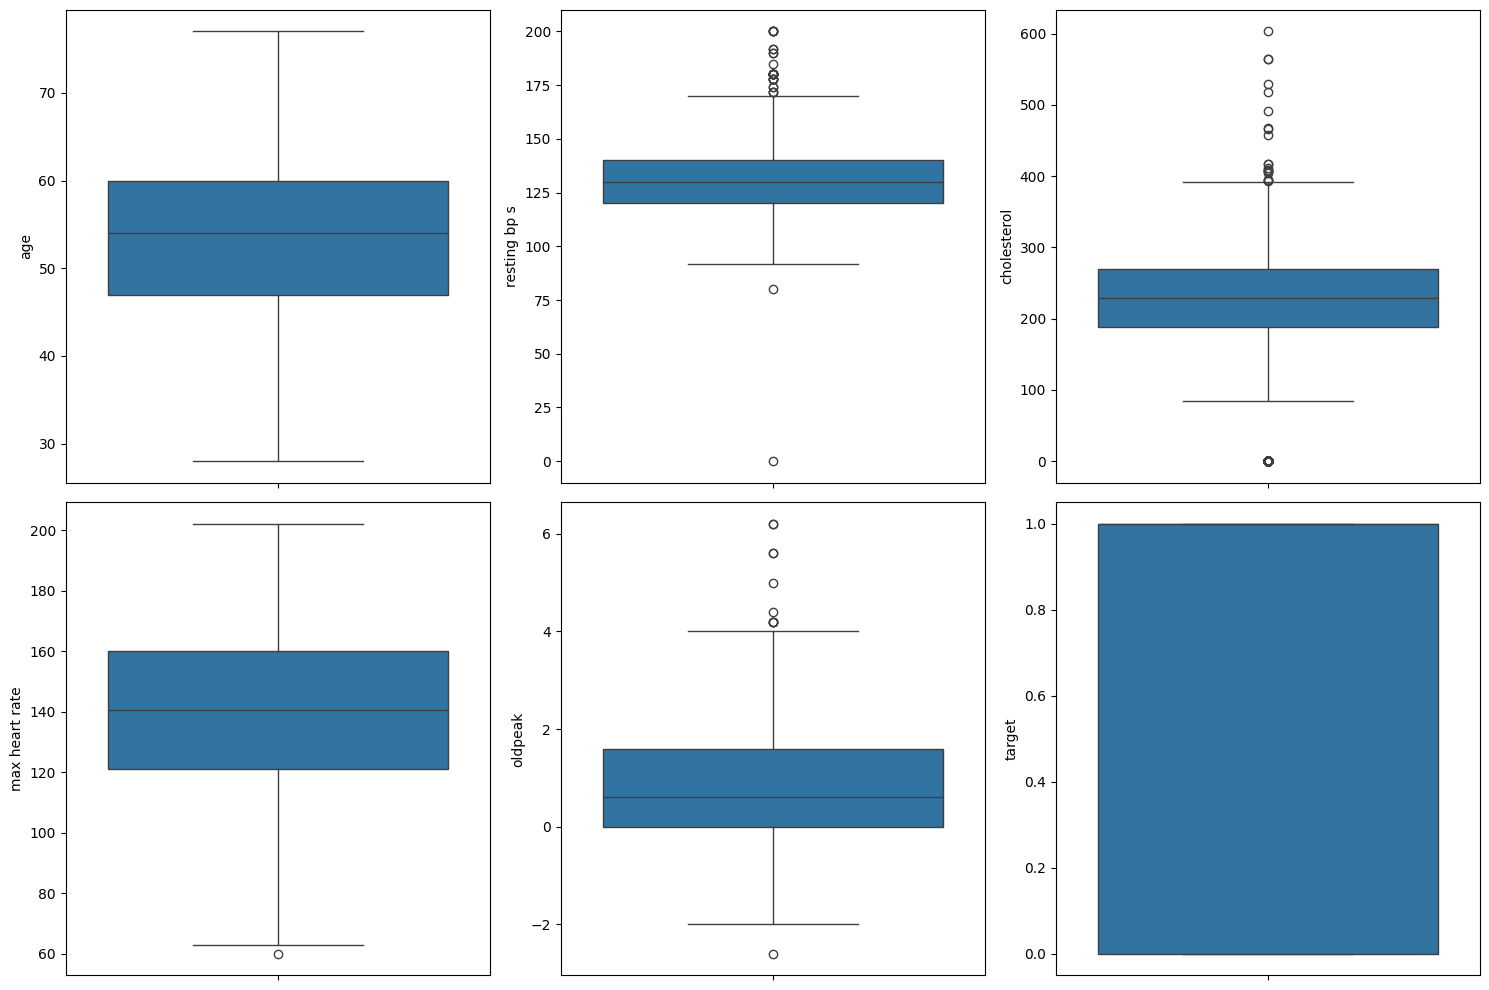

In [161]:
fig, axs = plt.subplots(2,3, figsize = (15,10))
plt1 = sns.boxplot(housing['age'], ax = axs[0,0])
plt2 = sns.boxplot(housing['resting bp s'], ax = axs[0,1])
plt3 = sns.boxplot(housing['cholesterol'], ax = axs[0,2])
plt4 = sns.boxplot(housing['max heart rate'], ax = axs[1,0])
plt5 = sns.boxplot(housing['oldpeak'], ax = axs[1,1])
plt6 = sns.boxplot(housing['target'], ax = axs[1,2])

plt.tight_layout()

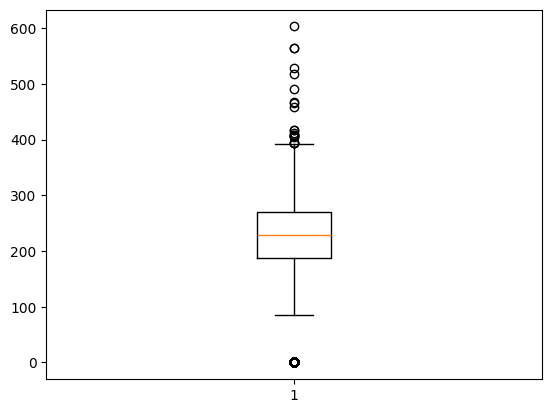

In [162]:

plt.boxplot(housing['cholesterol'])
Q1 = housing['cholesterol'].quantile(0.25)
Q3 = housing['cholesterol'].quantile(0.75)
IQR = Q3 - Q1
housing = housing[(housing['cholesterol'] >= Q1 - 1.5*IQR) & (housing['cholesterol'] <= Q3 + 1.5*IQR)]

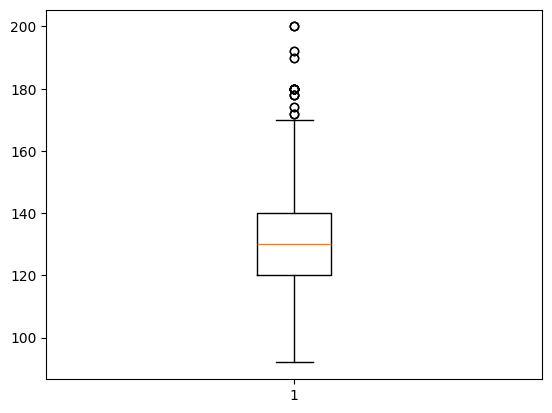

In [163]:

plt.boxplot(housing['resting bp s'])
Q1 = housing['resting bp s'].quantile(0.25)
Q3 = housing['resting bp s'].quantile(0.75)
IQR = Q3 - Q1
housing = housing[(housing['resting bp s'] >= Q1 - 1.5*IQR) & (housing['resting bp s'] <= Q3 + 1.5*IQR)]

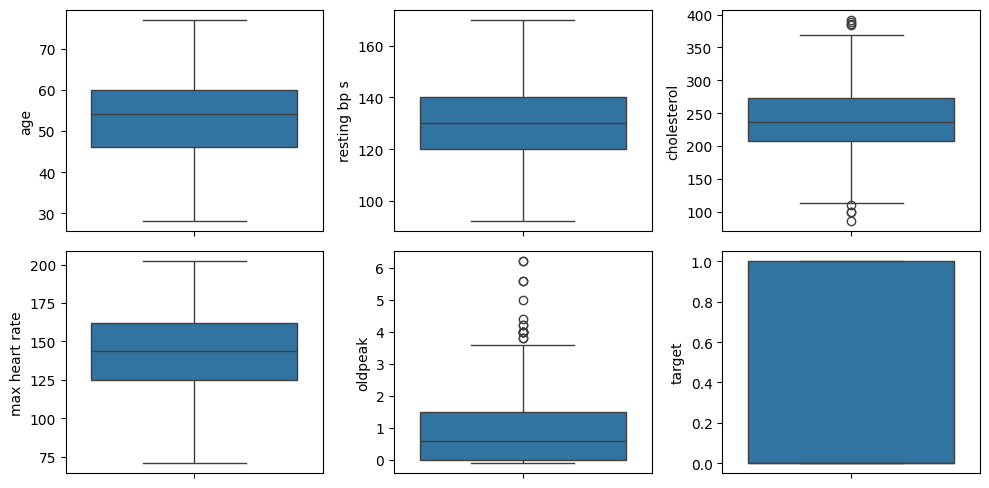

In [164]:

fig, axs = plt.subplots(2,3, figsize = (10,5))
plt1 = sns.boxplot(housing['age'], ax = axs[0,0])
plt2 = sns.boxplot(housing['resting bp s'], ax = axs[0,1])
plt3 = sns.boxplot(housing['cholesterol'], ax = axs[0,2])
plt4 = sns.boxplot(housing['max heart rate'], ax = axs[1,0])
plt5 = sns.boxplot(housing['oldpeak'], ax = axs[1,1])
plt6 = sns.boxplot(housing['target'], ax = axs[1,2])

plt.tight_layout()

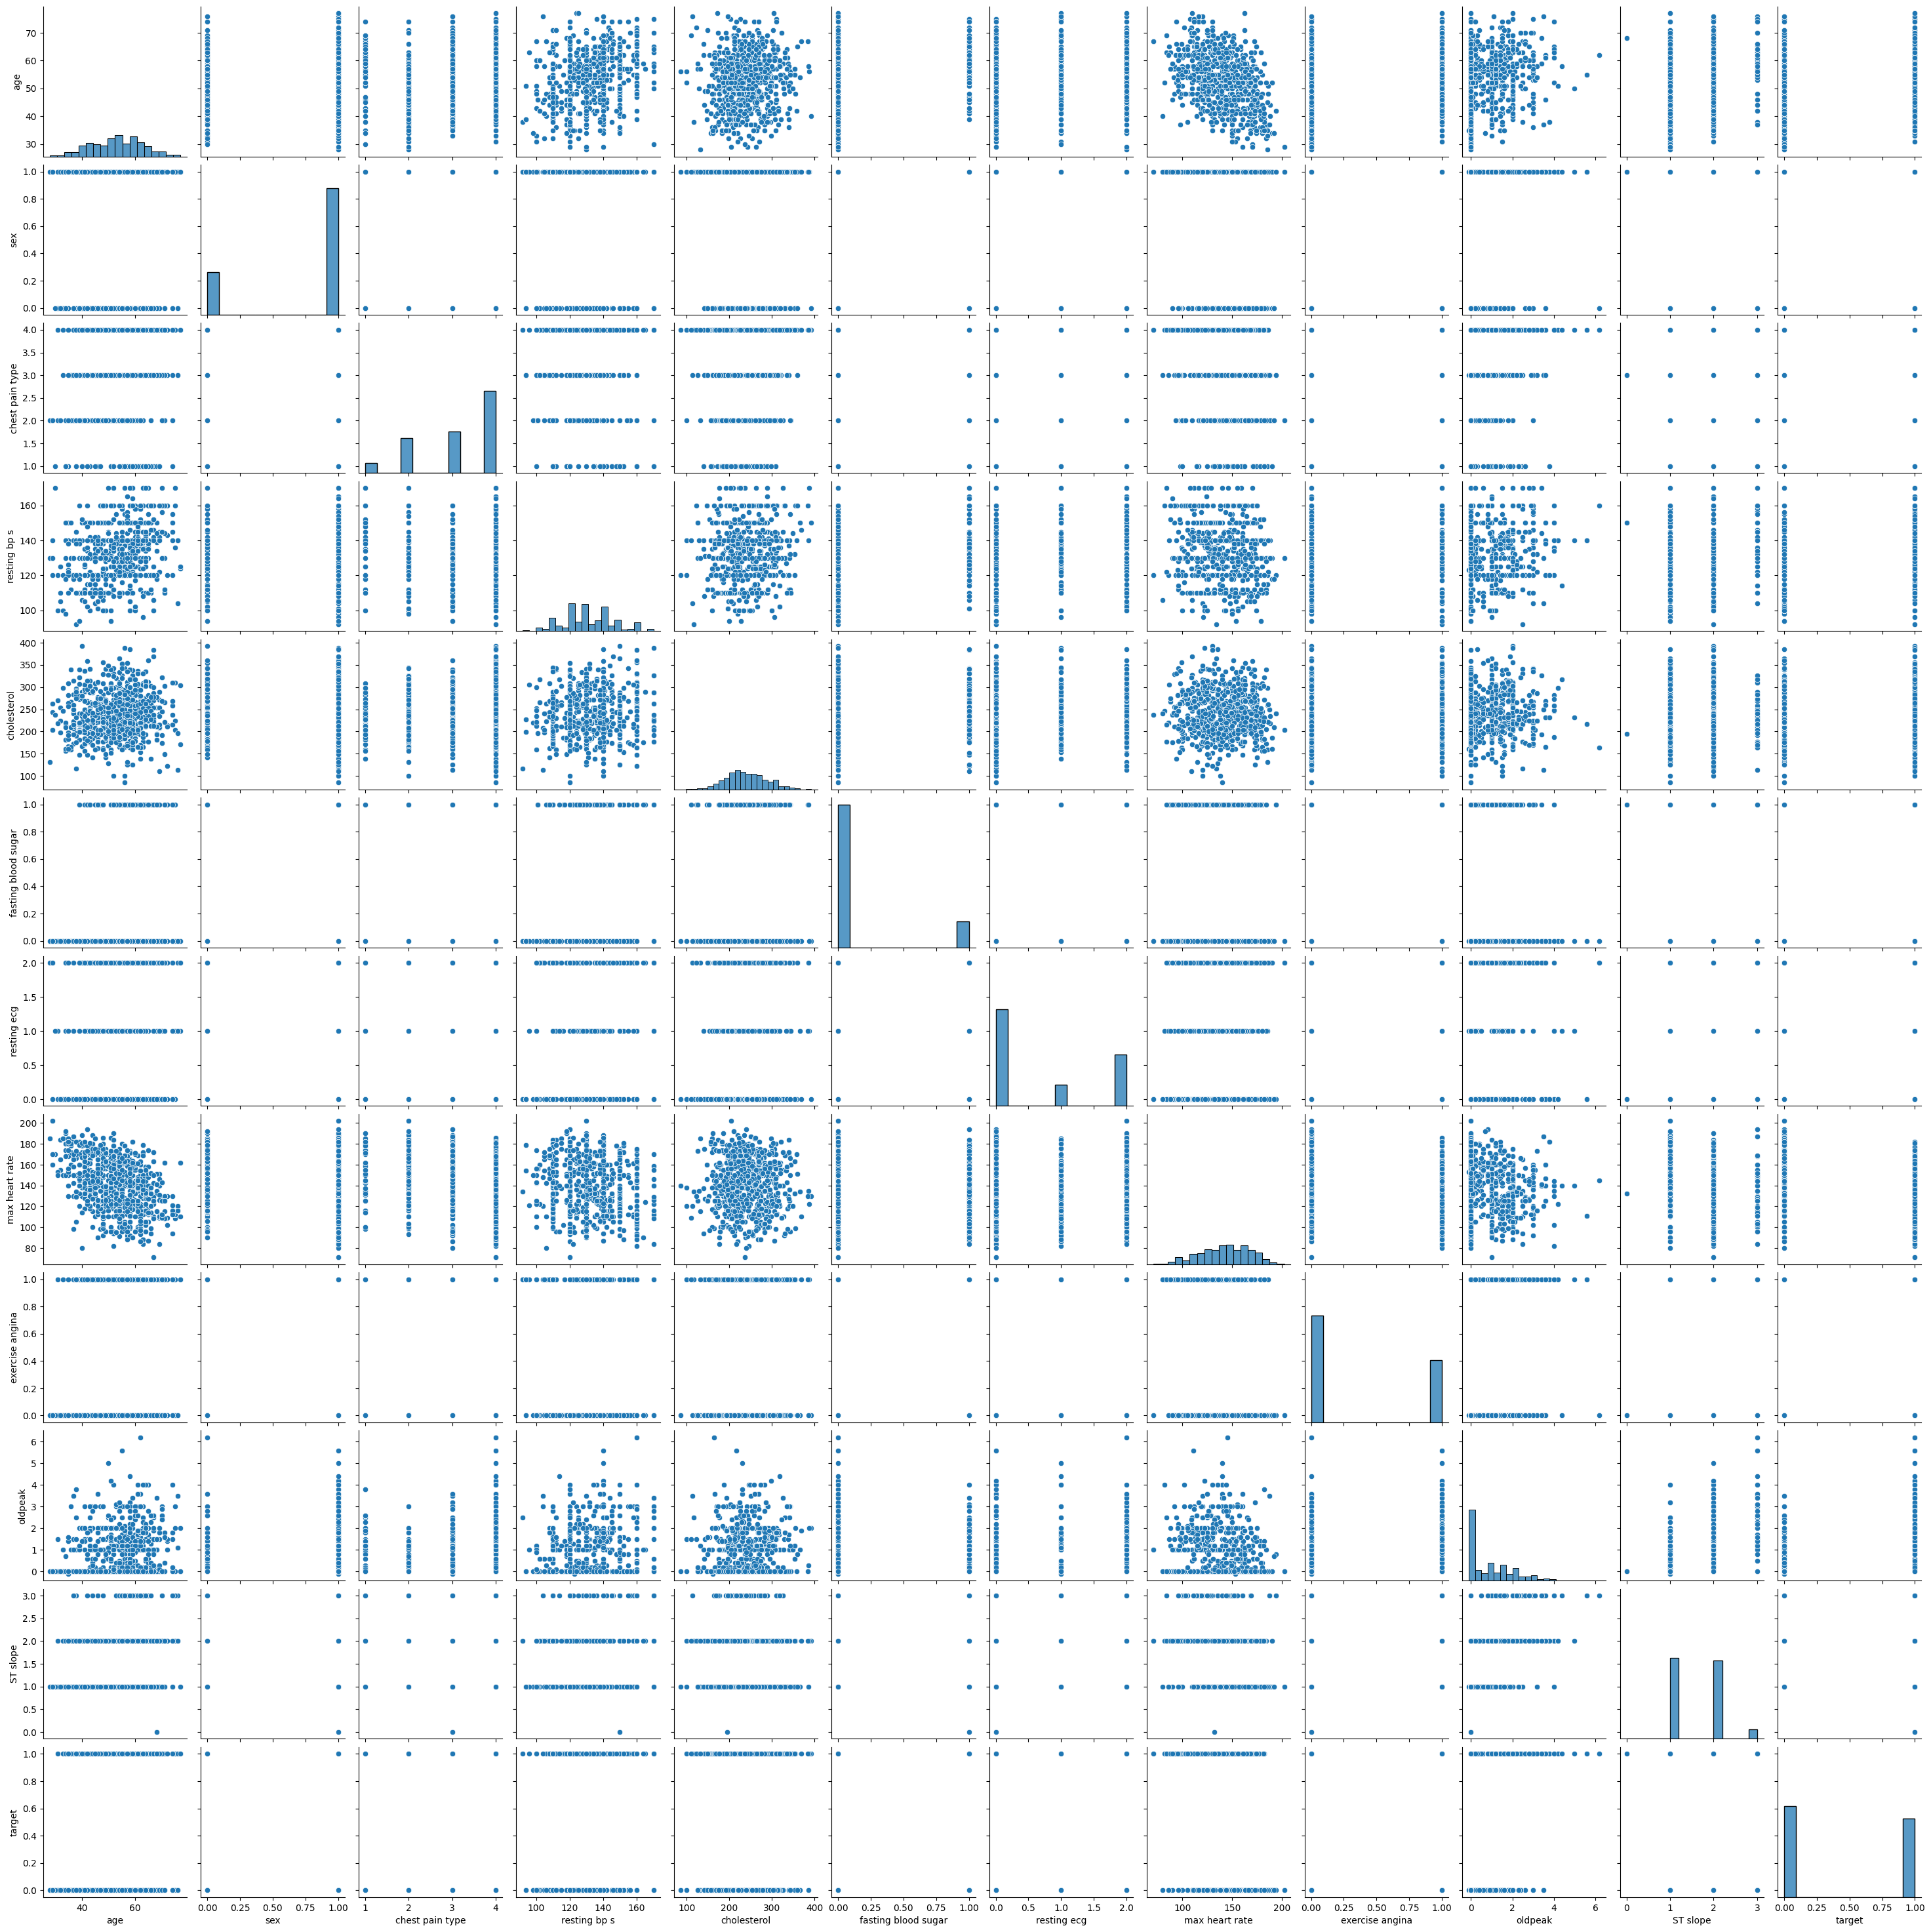

In [165]:
sns.pairplot(housing)
plt.show()

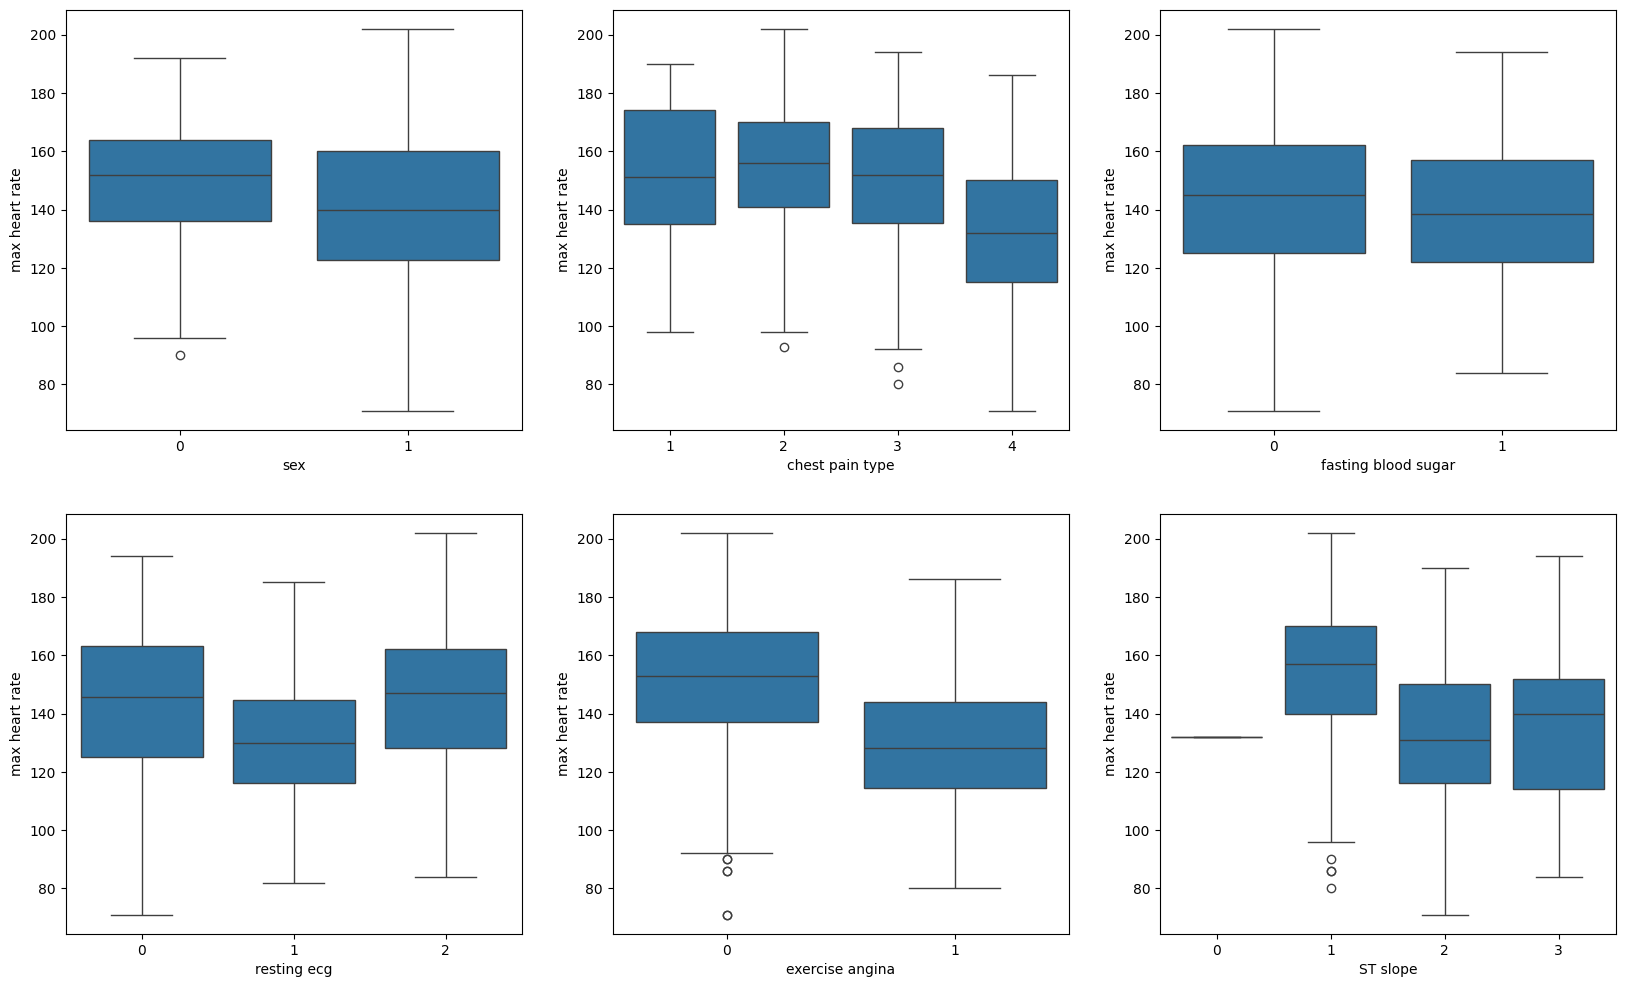

In [166]:
plt.figure(figsize=(20, 12))
plt.subplot(2,3,1)
sns.boxplot(x = 'sex', y = 'max heart rate', data = housing)
plt.subplot(2,3,2)
sns.boxplot(x = 'chest pain type', y = 'max heart rate', data = housing)
plt.subplot(2,3,3)
sns.boxplot(x = 'fasting blood sugar', y = 'max heart rate', data = housing)
plt.subplot(2,3,4)
sns.boxplot(x = 'resting ecg', y = 'max heart rate', data = housing)
plt.subplot(2,3,5)
sns.boxplot(x = 'exercise angina', y = 'max heart rate', data = housing)
plt.subplot(2,3,6)
sns.boxplot(x = 'ST slope', y = 'max heart rate', data = housing)
plt.show()

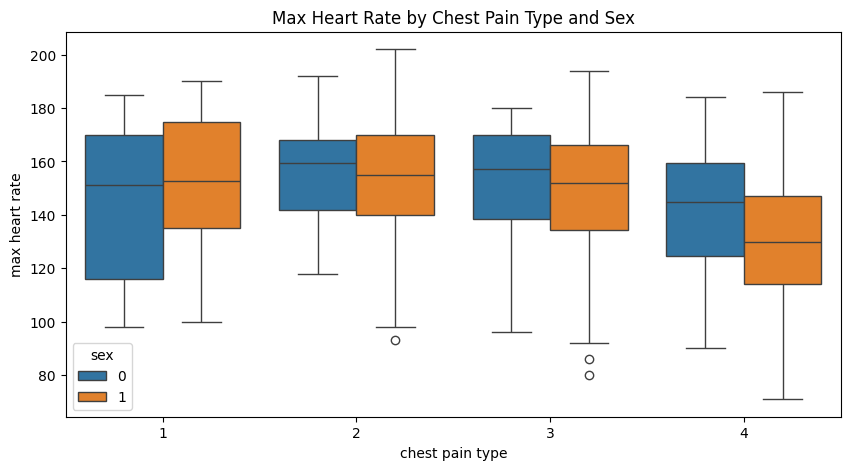

In [167]:
plt.figure(figsize = (10, 5))
sns.boxplot(x = 'chest pain type', y = 'max heart rate', hue = 'sex', data = housing)
plt.title('Max Heart Rate by Chest Pain Type and Sex')
plt.show()

In [168]:


housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 969 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  969 non-null    int64  
 1   sex                  969 non-null    int64  
 2   chest pain type      969 non-null    int64  
 3   resting bp s         969 non-null    int64  
 4   cholesterol          969 non-null    int64  
 5   fasting blood sugar  969 non-null    int64  
 6   resting ecg          969 non-null    int64  
 7   max heart rate       969 non-null    int64  
 8   exercise angina      969 non-null    int64  
 9   oldpeak              969 non-null    float64
 10  ST slope             969 non-null    int64  
 11  target               969 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 98.4 KB


In [169]:


housing.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [170]:

pass

In [171]:

housing.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [172]:

status = pd.get_dummies(housing['chest pain type'], prefix='cp', drop_first=True)
status.head()

,cp_2,cp_3,cp_4
0,True,False,False
1,False,True,False
2,True,False,False
3,False,False,True
4,False,True,False


In [173]:


housing = pd.concat([housing, status], axis = 1)

In [174]:


housing.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target,cp_2,cp_3,cp_4
0,40,1,2,140,289,0,0,172,0,0.0,1,0,True,False,False
1,49,0,3,160,180,0,0,156,0,1.0,2,1,False,True,False
2,37,1,2,130,283,0,1,98,0,0.0,1,0,True,False,False
3,48,0,4,138,214,0,0,108,1,1.5,2,1,False,False,True
4,54,1,3,150,195,0,0,122,0,0.0,1,0,False,True,False


In [175]:

pass

In [176]:
housing.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target,cp_2,cp_3,cp_4
0,40,1,2,140,289,0,0,172,0,0.0,1,0,True,False,False
1,49,0,3,160,180,0,0,156,0,1.0,2,1,False,True,False
2,37,1,2,130,283,0,1,98,0,0.0,1,0,True,False,False
3,48,0,4,138,214,0,0,108,1,1.5,2,1,False,False,True
4,54,1,3,150,195,0,0,122,0,0.0,1,0,False,True,False


In [177]:
from sklearn.model_selection import train_test_split


np.random.seed(0)
df_train, df_test = train_test_split(housing, train_size = 0.7, test_size = 0.3, random_state = 100)

In [178]:
from sklearn.preprocessing import MinMaxScaler

In [179]:
scaler = MinMaxScaler()

In [180]:

num_vars = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

In [181]:
df_train.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target,cp_2,cp_3,cp_4
229,0.250000,1,2,0.342105,0.739437,0,0,0.755725,0,0.015873,1,0,True,False,False
752,0.354167,0,3,0.631579,0.323944,0,2,0.679389,1,0.238095,3,0,False,True,False
731,0.270833,1,2,0.342105,0.739437,0,0,0.694656,0,0.015873,1,0,True,False,False
117,0.625000,0,4,0.473684,0.890845,1,1,0.450382,1,0.253968,2,1,False,False,True
490,0.520833,1,4,0.552632,0.475352,0,0,0.526718,1,0.492063,2,1,False,False,True


In [182]:
df_train.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000,678.000000
mean,0.508081,0.741888,3.132743,0.492470,0.549119,0.154867,0.753687,0.549573,0.377581,0.162078,1.592920,0.471976
std,0.193013,0.437919,0.963172,0.203804,0.167488,0.362045,0.904499,0.188096,0.485140,0.167255,0.607251,0.499583
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.354167,0.000000,2.000000,0.342105,0.433099,0.000000,0.000000,0.412214,0.000000,0.015873,1.000000,0.000000
50%,0.520833,1.000000,3.000000,0.473684,0.535211,0.000000,0.000000,0.557252,0.000000,0.111111,2.000000,0.000000
75%,0.645833,1.000000,4.000000,0.605263,0.661972,0.000000,2.000000,0.694656,1.000000,0.253968,2.000000,1.000000
max,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,3.000000,1.000000


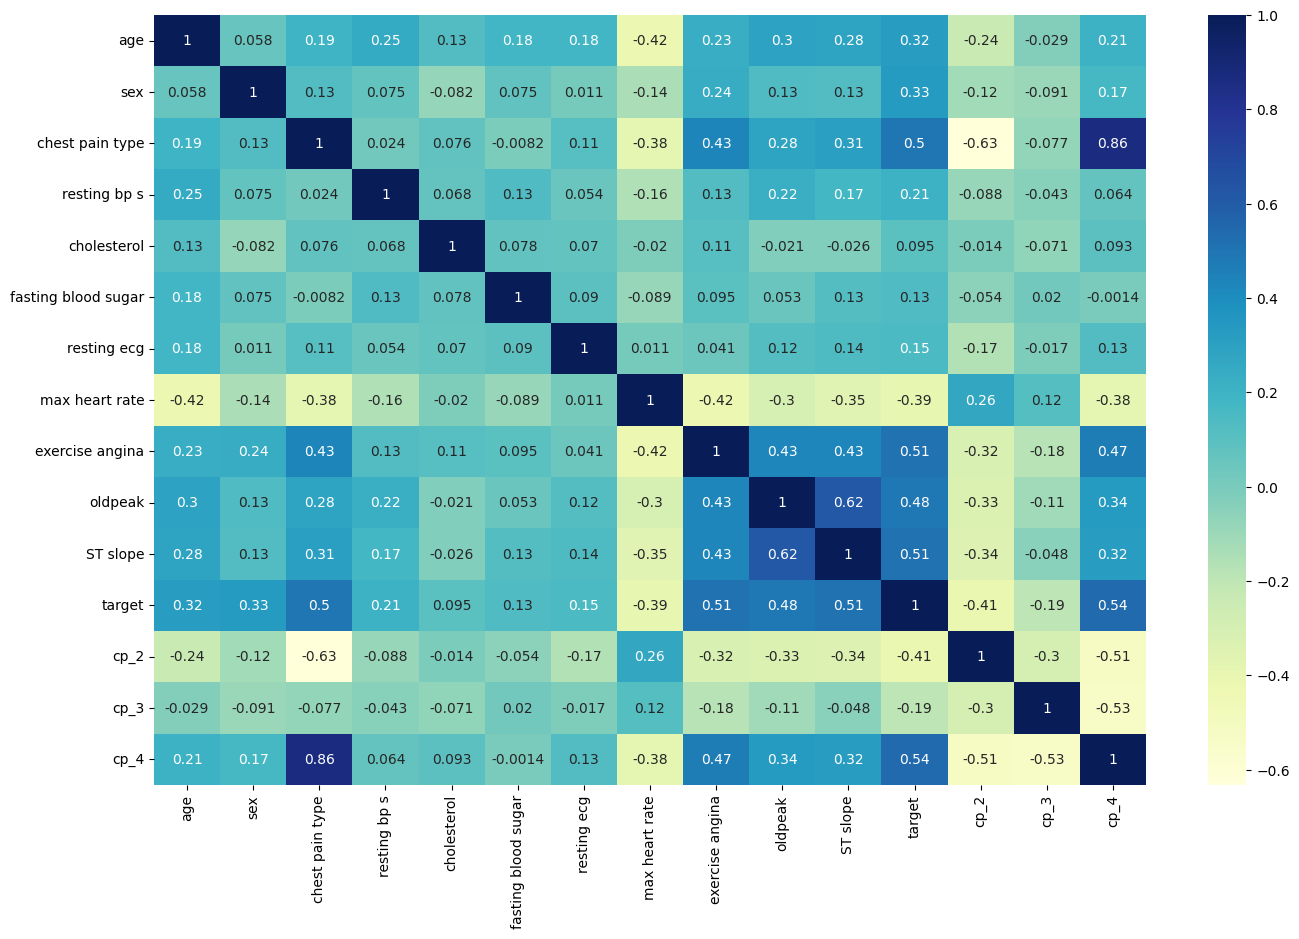

In [183]:


plt.figure(figsize = (16, 10))
sns.heatmap(df_train.corr(), annot = True, cmap="YlGnBu")
plt.show()

In [184]:
y_train = df_train.pop('target')
X_train = df_train

In [185]:

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [186]:

lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

In [187]:
rfe = RFE(estimator=lm, n_features_to_select=6)             # running RFE
rfe = rfe.fit(X_train, y_train)

In [188]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('age', np.True_, np.int64(1)),
 ('sex', np.True_, np.int64(1)),
 ('chest pain type', np.False_, np.int64(7)),
 ('resting bp s', np.False_, np.int64(2)),
 ('cholesterol', np.True_, np.int64(1)),
 ('fasting blood sugar', np.False_, np.int64(8)),
 ('resting ecg', np.False_, np.int64(9)),
 ('max heart rate', np.False_, np.int64(4)),
 ('exercise angina', np.False_, np.int64(3)),
 ('oldpeak', np.True_, np.int64(1)),
 ('ST slope', np.True_, np.int64(1)),
 ('cp_2', np.False_, np.int64(6)),
 ('cp_3', np.False_, np.int64(5)),
 ('cp_4', np.True_, np.int64(1))]

In [189]:
col = X_train.columns[rfe.support_]
col

Index(['age', 'sex', 'cholesterol', 'oldpeak', 'ST slope', 'cp_4'], dtype='object')

In [190]:
X_train.columns[~rfe.support_]

Index(['chest pain type', 'resting bp s', 'fasting blood sugar', 'resting ecg',
       'max heart rate', 'exercise angina', 'cp_2', 'cp_3'],
      dtype='object')

In [191]:

X_train_rfe = X_train[col]

In [192]:

import statsmodels.api as sm
X_train_rfe = sm.add_constant(X_train_rfe)

In [193]:
import numpy as np

lm = sm.OLS(y_train.astype(float), X_train_rfe.astype(float)).fit()   # Running the linear model

In [194]:

print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     115.1
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.16e-99
Time:                        15:28:50   Log-Likelihood:                -251.14
No. Observations:                 678   AIC:                             516.3
Df Residuals:                     671   BIC:                             547.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.5519      0.068     -8.080      

In [195]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [196]:
vif = pd.DataFrame()

X = X_train_rfe.astype(float)
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,const,25.49
4,oldpeak,1.72
5,ST slope,1.68
6,cp_4,1.20
1,age,1.15
2,sex,1.05
3,cholesterol,1.04


In [197]:
y_train_price = lm.predict(X_train_rfe)

In [198]:
res = (y_train_price - y_train)

In [199]:

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0.5, 0, 'Errors')

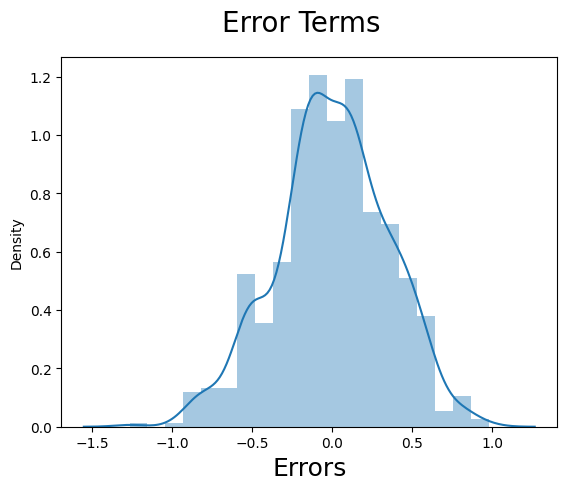

In [200]:

fig = plt.figure()
sns.distplot((y_train - y_train_price), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)
plt.xlabel('Errors', fontsize = 18)

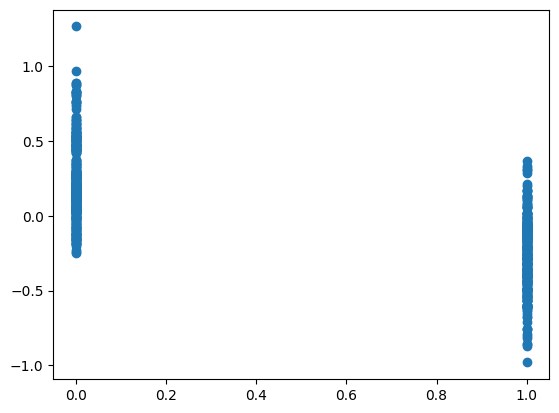

In [201]:
plt.scatter(y_train,res)
plt.show()

In [202]:
num_vars = ['area','stories', 'bathrooms', 'airconditioning', 'prefarea','parking','price']

In [203]:

num_vars = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']


df_test[num_vars] = scaler.transform(df_test[num_vars])

In [204]:

y_test = df_test.pop('target')
X_test = df_test

In [205]:

X_test = sm.add_constant(X_test)

In [206]:

X_test_rfe = X_test[X_train_rfe.columns]

In [207]:

y_pred = lm.predict(X_test_rfe)

In [208]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.44607897237852734

Text(0, 0.5, 'y_pred')

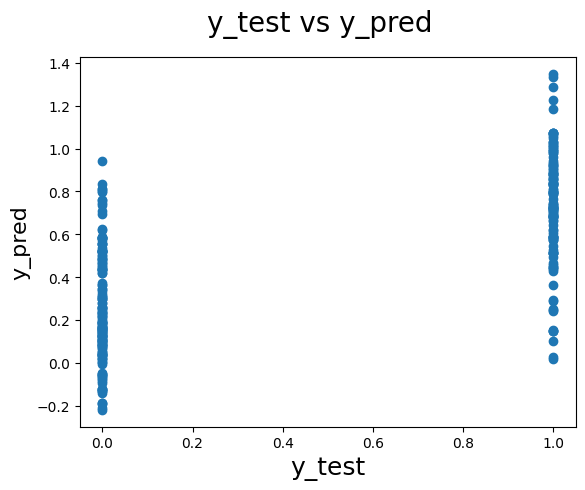

In [209]:

fig = plt.figure()
plt.scatter(y_test,y_pred)
fig.suptitle('y_test vs y_pred', fontsize=20)
plt.xlabel('y_test', fontsize=18)
plt.ylabel('y_pred', fontsize=16)


We can see that the equation of our best fitted line is:

$ price = 0.35  \times  area + 0.20  \times  bathrooms + 0.19 \times stories+ 0.10 \times airconditioning + 0.10 \times parking + 0.11 \times prefarea $
